# E-Commerce Customer Segmentation
### Dataset: Online Retail II
## Final Enhanced Notebook

This notebook presents an improved framework:
- Robust preprocessing
- RFM + advanced behavioral features
- Multiple clustering methods
- Ablation study
- Model comparison with multiple metrics
- Business interpretation


## 1. Import Libraries

In this section, we import all required Python libraries for data processing, visualization, and clustering.

- Pandas and NumPy are used for data manipulation.
- Matplotlib and Seaborn are used for visualization.
- Scikit-learn provides clustering algorithms and evaluation metrics.
- PCA is used for dimensionality reduction and visualization.
- Warnings are suppressed for cleaner output.

A fixed random state is used to ensure reproducibility of results.

In [1]:
import warnings
warnings.filterwarnings("ignore")

import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from pathlib import Path
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score
from scipy.cluster.hierarchy import linkage, dendrogram

sns.set_style("whitegrid")
RANDOM_STATE = 42


## 2. Load Dataset

The dataset is loaded  Excel (.xlsx) using openpyxl a flexible loading function and the dataset is then inspected by printing its shape and previewing the first few rows.

In [2]:
dataset_path = Path("data/online_retail_II.xlsx")
if not dataset_path.exists():
    dataset_path = Path("../data/online_retail_II.xlsx")

df = pd.read_excel(dataset_path)

print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (525461, 8)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom


## 3. Initial Inspection

In this step, we examine the dataset structure:

- Column names are cleaned to remove extra spaces
- Data types and non-null counts are checked
- Missing values are identified

This helps us understand data quality and prepare for cleaning.

In [3]:
df.columns = df.columns.str.strip()
print(df.columns.tolist())
df.info()


['Invoice', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'Price', 'Customer ID', 'Country']
<class 'pandas.DataFrame'>
RangeIndex: 525461 entries, 0 to 525460
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   Invoice      525461 non-null  object        
 1   StockCode    525461 non-null  object        
 2   Description  522533 non-null  object        
 3   Quantity     525461 non-null  int64         
 4   InvoiceDate  525461 non-null  datetime64[us]
 5   Price        525461 non-null  float64       
 6   Customer ID  417534 non-null  float64       
 7   Country      525461 non-null  str           
dtypes: datetime64[us](1), float64(2), int64(1), object(3), str(1)
memory usage: 38.8+ MB


In [4]:
df.isnull().sum().sort_values(ascending=False)


Customer ID    107927
Description      2928
Invoice             0
StockCode           0
Quantity            0
InvoiceDate         0
Price               0
Country             0
dtype: int64

## 4. Detect Required Columns

Since different versions of the dataset may have slightly different column names, we dynamically detect:

- Price column (Price or UnitPrice)
- Customer ID column
- Invoice column
- Date column
- Quantity column

This makes the pipeline robust and adaptable to variations in the dataset.

In [5]:
price_col = next((c for c in ["Price", "UnitPrice", "Unit Price"] if c in df.columns), None)
cust_col = next((c for c in ["Customer ID", "CustomerID", "CustomerId"] if c in df.columns), None)
invoice_col = "Invoice" if "Invoice" in df.columns else "InvoiceNo"
date_col = "InvoiceDate" if "InvoiceDate" in df.columns else "Invoice Date"
qty_col = "Quantity"
desc_col = "Description" if "Description" in df.columns else None
stock_col = "StockCode" if "StockCode" in df.columns else None
country_col = "Country" if "Country" in df.columns else None

if price_col is None:
    raise KeyError(f"Price column not found. Available columns: {list(df.columns)}")
if cust_col is None:
    raise KeyError(f"Customer ID column not found. Available columns: {list(df.columns)}")

print("price_col:", price_col)
print("cust_col:", cust_col)
print("invoice_col:", invoice_col)
print("date_col:", date_col)
print("qty_col:", qty_col)
print("desc_col:", desc_col)
print("stock_col:", stock_col)
print("country_col:", country_col)


price_col: Price
cust_col: Customer ID
invoice_col: Invoice
date_col: InvoiceDate
qty_col: Quantity
desc_col: Description
stock_col: StockCode
country_col: Country


## 5. Data Cleaning

Real-world transaction data contains noise and inconsistencies.

We perform the following cleaning steps:

- Remove rows with missing Customer IDs
- Remove cancelled invoices (identified by 'C' prefix)
- Remove negative or zero quantities (returns or invalid entries)
- Remove invalid price values
- Convert the date column to datetime format

Finally, we create a new feature:
- TotalAmount = Quantity × Price

This ensures that only valid purchase transactions are used for analysis.

In [6]:
df = df.dropna(subset=[cust_col]).copy()

df[invoice_col] = df[invoice_col].astype(str)
df = df[~df[invoice_col].str.startswith("C")]

df = df[(df[qty_col] > 0) & (df[price_col] > 0)]

df[date_col] = pd.to_datetime(df[date_col], errors="coerce")
df = df.dropna(subset=[date_col])

df["TotalAmount"] = df[qty_col] * df[price_col]

print("Cleaned dataset shape:", df.shape)
df.head()


Cleaned dataset shape: (407664, 9)


,Invoice,StockCode,Description,Quantity,InvoiceDate,Price,Customer ID,Country,TotalAmount
0,489434,85048,15CM CHRISTMAS GLASS BALL 20 LIGHTS,12,2009-12-01 07:45:00,6.95,13085.0,United Kingdom,83.4
1,489434,79323P,PINK CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
2,489434,79323W,WHITE CHERRY LIGHTS,12,2009-12-01 07:45:00,6.75,13085.0,United Kingdom,81.0
3,489434,22041,"RECORD FRAME 7"" SINGLE SIZE",48,2009-12-01 07:45:00,2.10,13085.0,United Kingdom,100.8
4,489434,21232,STRAWBERRY CERAMIC TRINKET BOX,24,2009-12-01 07:45:00,1.25,13085.0,United Kingdom,30.0


## 6. Feature Engineering: RFM Model (Enhanced)

To transform transaction-level data into customer-level behavioral features, we adopt the widely used **RFM (Recency, Frequency, Monetary) model**.

The RFM model captures three key aspects of customer behavior:

- **Recency (R)**: The number of days since a customer’s most recent purchase. Lower values indicate more recent activity and higher engagement.
- **Frequency (F)**: The total number of transactions made by a customer. Higher values indicate more frequent purchasing behavior.
- **Monetary (M)**: The total amount spent by the customer. Higher values represent more valuable customers.

To compute these features, we first define a reference date (snapshot date) as one day after the last transaction in the dataset. Recency is calculated relative to this date.

The resulting RFM representation provides a compact and interpretable summary of customer behavior, which serves as the foundation for clustering and further feature engineering.

In [7]:
# Define snapshot date (reference point)
snapshot_date = df[date_col].max() + pd.Timedelta(days=1)

# Recency: days since last purchase
recency = (
    df.groupby(cust_col)[date_col]
      .max()
      .reset_index()
)
recency["Recency"] = (snapshot_date - recency[date_col]).dt.days
recency = recency[[cust_col, "Recency"]]

# Frequency: number of unique invoices
frequency = (
    df.groupby(cust_col)[invoice_col]
      .nunique()
      .reset_index(name="Frequency")
)

# Monetary: total spending
monetary = (
    df.groupby(cust_col)["TotalAmount"]
      .sum()
      .reset_index(name="Monetary")
)

# Merge RFM features
rfm = recency.merge(frequency, on=cust_col).merge(monetary, on=cust_col)

# Basic sanity checks
print("RFM Table Shape:", rfm.shape)
print("\nRFM Summary Statistics:")
display(rfm.describe())

rfm.head()

RFM Table Shape: (4312, 4)

RFM Summary Statistics:


,Customer ID,Recency,Frequency,Monetary
count,4312.000000,4312.000000,4312.000000,4312.000000
mean,15349.290353,91.171846,4.455705,2048.238236
std,1701.200176,96.860633,8.170213,8914.481280
min,12346.000000,1.000000,1.000000,2.950000
25%,13882.500000,18.000000,1.000000,307.987500
50%,15350.500000,53.000000,2.000000,706.020000
75%,16834.250000,136.000000,5.000000,1723.142500
max,18287.000000,374.000000,205.000000,349164.350000


,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93


## RFM Distribtion Visualization

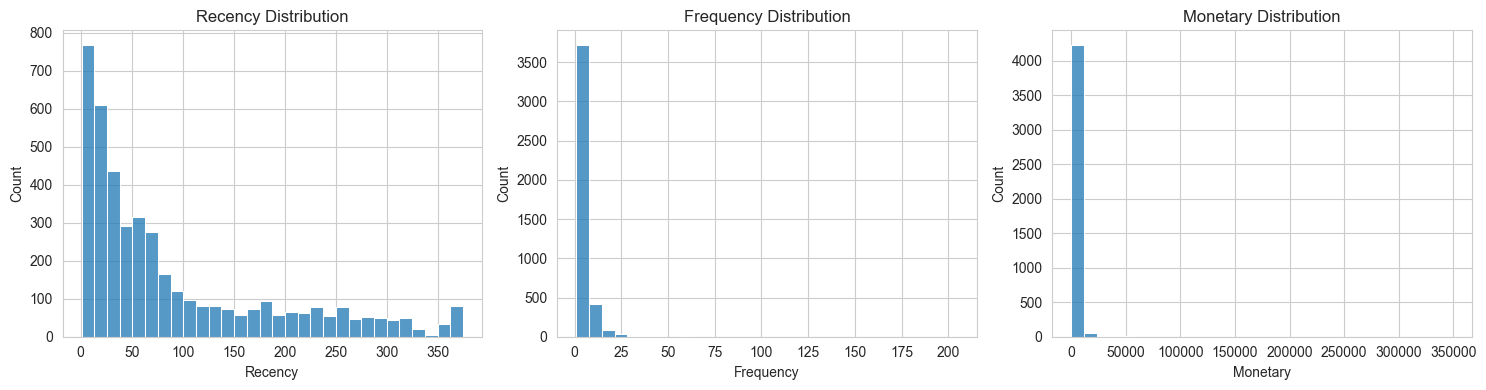

In [8]:
plt.figure(figsize=(15,4))

plt.subplot(1,3,1)
sns.histplot(rfm["Recency"], bins=30)
plt.title("Recency Distribution")

plt.subplot(1,3,2)
sns.histplot(rfm["Frequency"], bins=30)
plt.title("Frequency Distribution")

plt.subplot(1,3,3)
sns.histplot(rfm["Monetary"], bins=30)
plt.title("Monetary Distribution")

plt.tight_layout()
plt.show()

## 7. Additional Feature Engineering (Final Version)

To enhance the segmentation model beyond traditional RFM features, we introduce additional behavioral and temporal features that capture deeper aspects of customer activity:

- **AvgOrderValue**: Represents the average spending per transaction, providing insight into customer purchasing power.
- **AvgQtyPerInvoice**: Measures the average quantity purchased per order, reflecting purchase volume behavior.
- **UniqueProducts**: Indicates the diversity of products purchased by a customer, capturing variety in shopping patterns.
- **PurchaseSpan**: Represents the duration between the first and last purchase, approximating customer lifetime.

In addition, we incorporate temporal and composite behavioral features:

- **PurchaseRate**: Frequency of purchases normalized by customer lifetime, capturing engagement intensity.
- **AvgDaysBetweenPurchases**: Measures the average interval between transactions, reflecting consistency of purchasing behavior.
- **ActivityScore**: A composite feature derived from RFM values, combining frequency, monetary value, and recency into a single engagement metric.

These extended features provide a more comprehensive representation of customer behavior, enabling improved cluster separation and more meaningful segmentation results.

In [9]:
# 1. Average Order Value (AOV)
aov = df.groupby(cust_col).apply(
    lambda x: x["TotalAmount"].sum() / x[invoice_col].nunique()
).reset_index(name="AvgOrderValue")

# Reduce skewness
aov["AvgOrderValue"] = np.log1p(aov["AvgOrderValue"])


# 2. Average Quantity per Invoice
avg_qty_per_invoice = df.groupby([cust_col, invoice_col])[qty_col].sum().reset_index()
avg_qty_per_invoice = avg_qty_per_invoice.groupby(cust_col)[qty_col].mean().reset_index()
avg_qty_per_invoice.columns = [cust_col, "AvgQtyPerInvoice"]


# 3. Unique Products Purchased
if stock_col is not None:
    unique_products = df.groupby(cust_col)[stock_col].nunique().reset_index()
else:
    unique_products = df.groupby(cust_col)[desc_col].nunique().reset_index()
unique_products.columns = [cust_col, "UniqueProducts"]


# 4. Purchase Span (Customer Lifetime)
purchase_span = df.groupby(cust_col)[date_col].agg(["min", "max"]).reset_index()
purchase_span["PurchaseSpan"] = (purchase_span["max"] - purchase_span["min"]).dt.days

# Fix zero values
purchase_span["PurchaseSpan"] = purchase_span["PurchaseSpan"].replace(0, 1)
purchase_span = purchase_span[[cust_col, "PurchaseSpan"]]


# 5. Purchase Rate (Frequency per day)
purchase_rate = frequency.merge(purchase_span, on=cust_col)
purchase_rate["PurchaseRate"] = purchase_rate["Frequency"] / purchase_rate["PurchaseSpan"]
purchase_rate = purchase_rate[[cust_col, "PurchaseRate"]]


# 6. Average Days Between Purchases
invoice_dates = df.groupby([cust_col, invoice_col])[date_col].min().reset_index()

avg_gap = invoice_dates.groupby(cust_col)[date_col].apply(
    lambda x: x.sort_values().diff().dt.days.mean()
).reset_index(name="AvgDaysBetweenPurchases")

# Handle missing values
avg_gap["AvgDaysBetweenPurchases"] = avg_gap["AvgDaysBetweenPurchases"].fillna(0)


# 7. Activity Score (Combined RFM)
activity_score = rfm.copy()
activity_score["ActivityScore"] = (
    (activity_score["Frequency"] * 0.4) +
    (activity_score["Monetary"] * 0.4) -
    (activity_score["Recency"] * 0.2)
)
activity_score = activity_score[[cust_col, "ActivityScore"]]


# -----------------------------
# Final Feature Merge
# -----------------------------
customer_features = (
    rfm
    .merge(aov, on=cust_col)
    .merge(avg_qty_per_invoice, on=cust_col)
    .merge(unique_products, on=cust_col)
    .merge(purchase_span, on=cust_col)
    .merge(purchase_rate, on=cust_col)
    .merge(avg_gap, on=cust_col)
    .merge(activity_score, on=cust_col)
)

# Final check
print("Final Feature Columns:")
print(customer_features.columns)

customer_features.head()


Final Feature Columns:
Index(['Customer ID', 'Recency', 'Frequency', 'Monetary', 'AvgOrderValue',
       'AvgQtyPerInvoice', 'UniqueProducts', 'PurchaseSpan', 'PurchaseRate',
       'AvgDaysBetweenPurchases', 'ActivityScore'],
      dtype='str')


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,AvgQtyPerInvoice,UniqueProducts,PurchaseSpan,PurchaseRate,AvgDaysBetweenPurchases,ActivityScore
0,12346.0,165,11,372.86,3.552383,6.363636,26,196,0.056122,19.2,120.544
1,12347.0,3,2,1323.32,6.496262,414.000000,70,37,0.054054,37.0,529.528
2,12348.0,74,1,222.16,5.407889,373.000000,20,1,1.000000,0.0,74.464
3,12349.0,43,3,2671.14,6.792771,331.000000,90,181,0.016575,90.0,1061.056
4,12351.0,11,1,300.93,5.710195,261.000000,21,1,1.000000,0.0,118.572


## 8. Exploratory Data Analysis 

In this section, we analyze the distribution and relationships of customer features to understand behavioral patterns and data characteristics.

We focus on:
- Distribution of RFM and behavioral features
- Feature relationships through correlation analysis
- Identification of outliers and skewness

Understanding these properties is essential before applying clustering algorithms, as clustering is sensitive to feature scale and distribution.

In [10]:
customer_features.describe().transpose()


,count,mean,std,min,25%,50%,75%,max
Customer ID,4312.0,15349.290353,1701.200176,12346.000000,13882.500000,15350.500000,16834.250000,18287.000000
Recency,4312.0,91.171846,96.860633,1.000000,18.000000,53.000000,136.000000,374.000000
Frequency,4312.0,4.455705,8.170213,1.000000,1.000000,2.000000,5.000000,205.000000
Monetary,4312.0,2048.238236,8914.481280,2.950000,307.987500,706.020000,1723.142500,349164.350000
AvgOrderValue,4312.0,5.638376,0.741331,1.373716,5.209966,5.664237,6.051093,9.382766
AvgQtyPerInvoice,4312.0,255.751540,1554.107975,1.000000,90.000000,151.916667,257.000000,87167.000000
UniqueProducts,4312.0,63.646104,85.757966,1.000000,17.000000,38.000000,79.250000,1741.000000
PurchaseSpan,4312.0,134.345779,132.477262,1.000000,1.000000,105.000000,254.000000,373.000000
PurchaseRate,4312.0,0.401294,0.524278,0.005540,0.020301,0.045113,1.000000,4.000000
AvgDaysBetweenPurchases,4312.0,46.744000,60.470626,0.000000,0.000000,28.379808,68.750000,361.000000


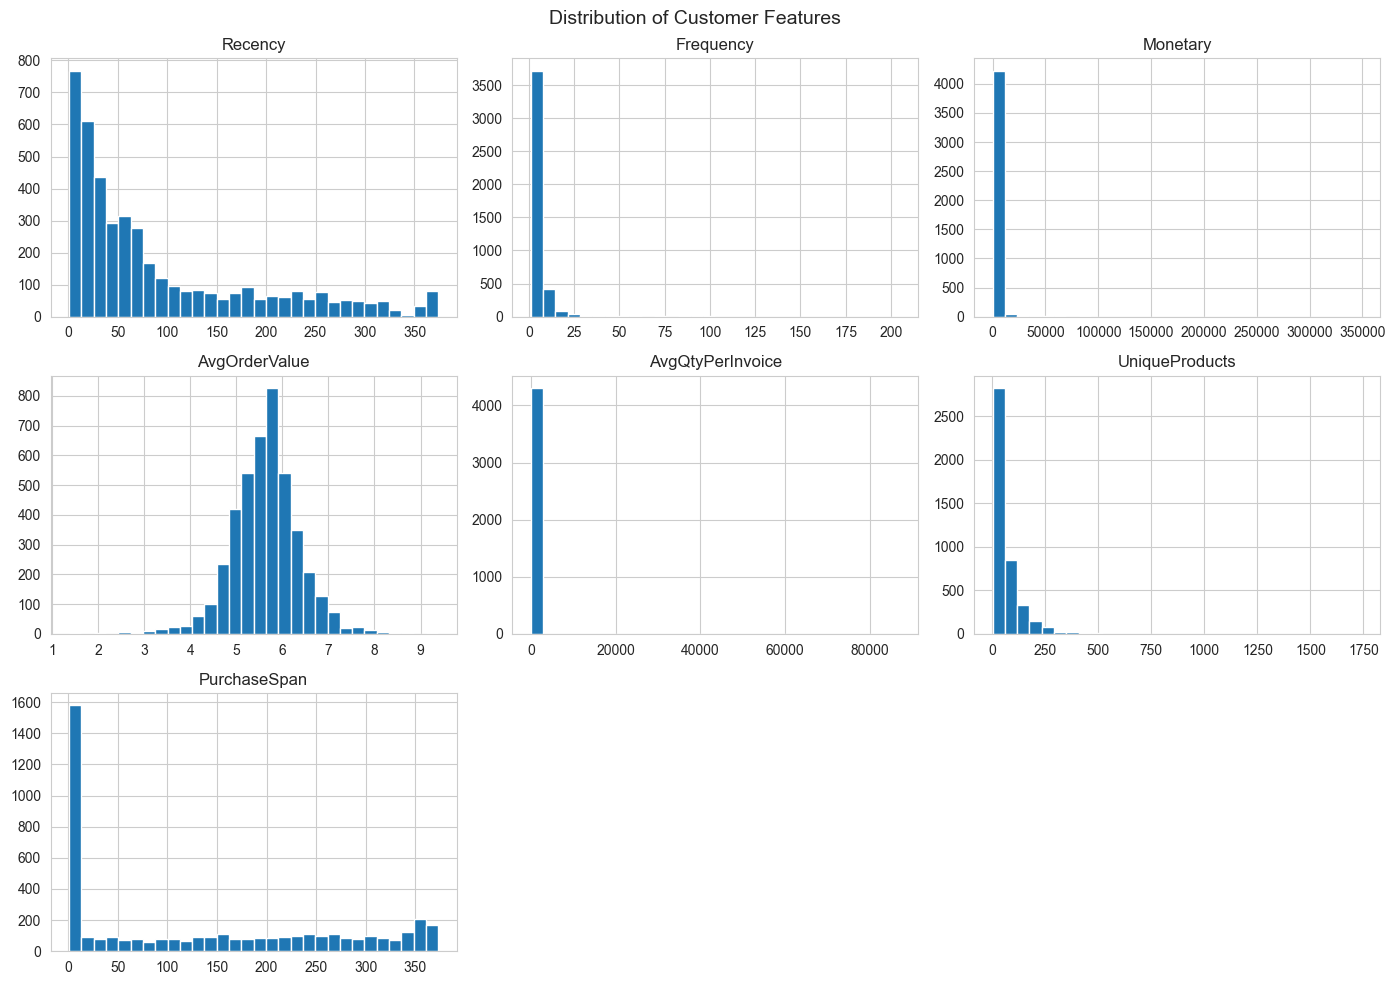

In [11]:
features_to_plot = [
    "Recency", "Frequency", "Monetary",
    "AvgOrderValue", "AvgQtyPerInvoice",
    "UniqueProducts", "PurchaseSpan"
]

customer_features[features_to_plot].hist(figsize=(14, 10), bins=30)
plt.suptitle("Distribution of Customer Features", fontsize=14)
plt.tight_layout()
plt.show()


## Correation Analysis

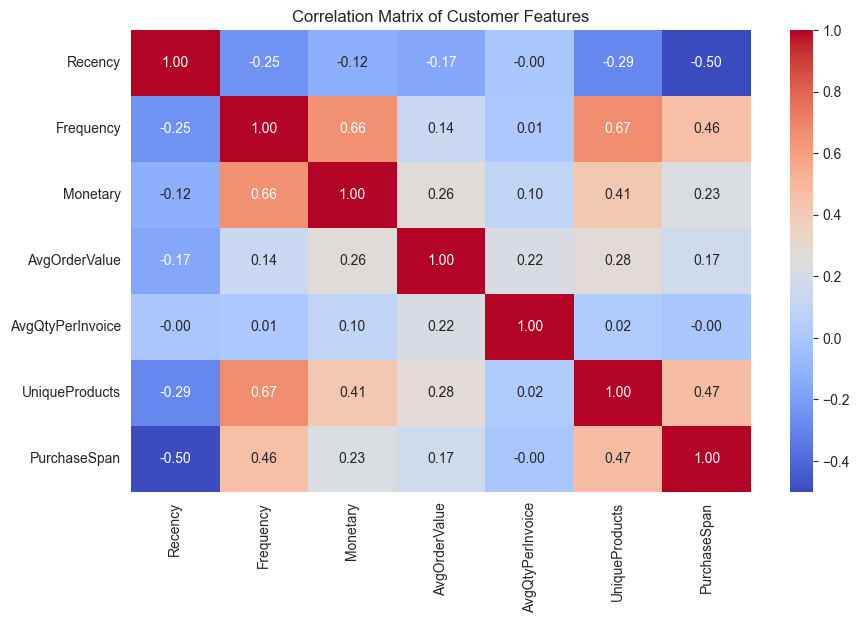

In [12]:
plt.figure(figsize=(10, 6))
sns.heatmap(customer_features[features_to_plot].corr(), 
            annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Matrix of Customer Features")
plt.show()

## Outlier Analysis (Boxplots)

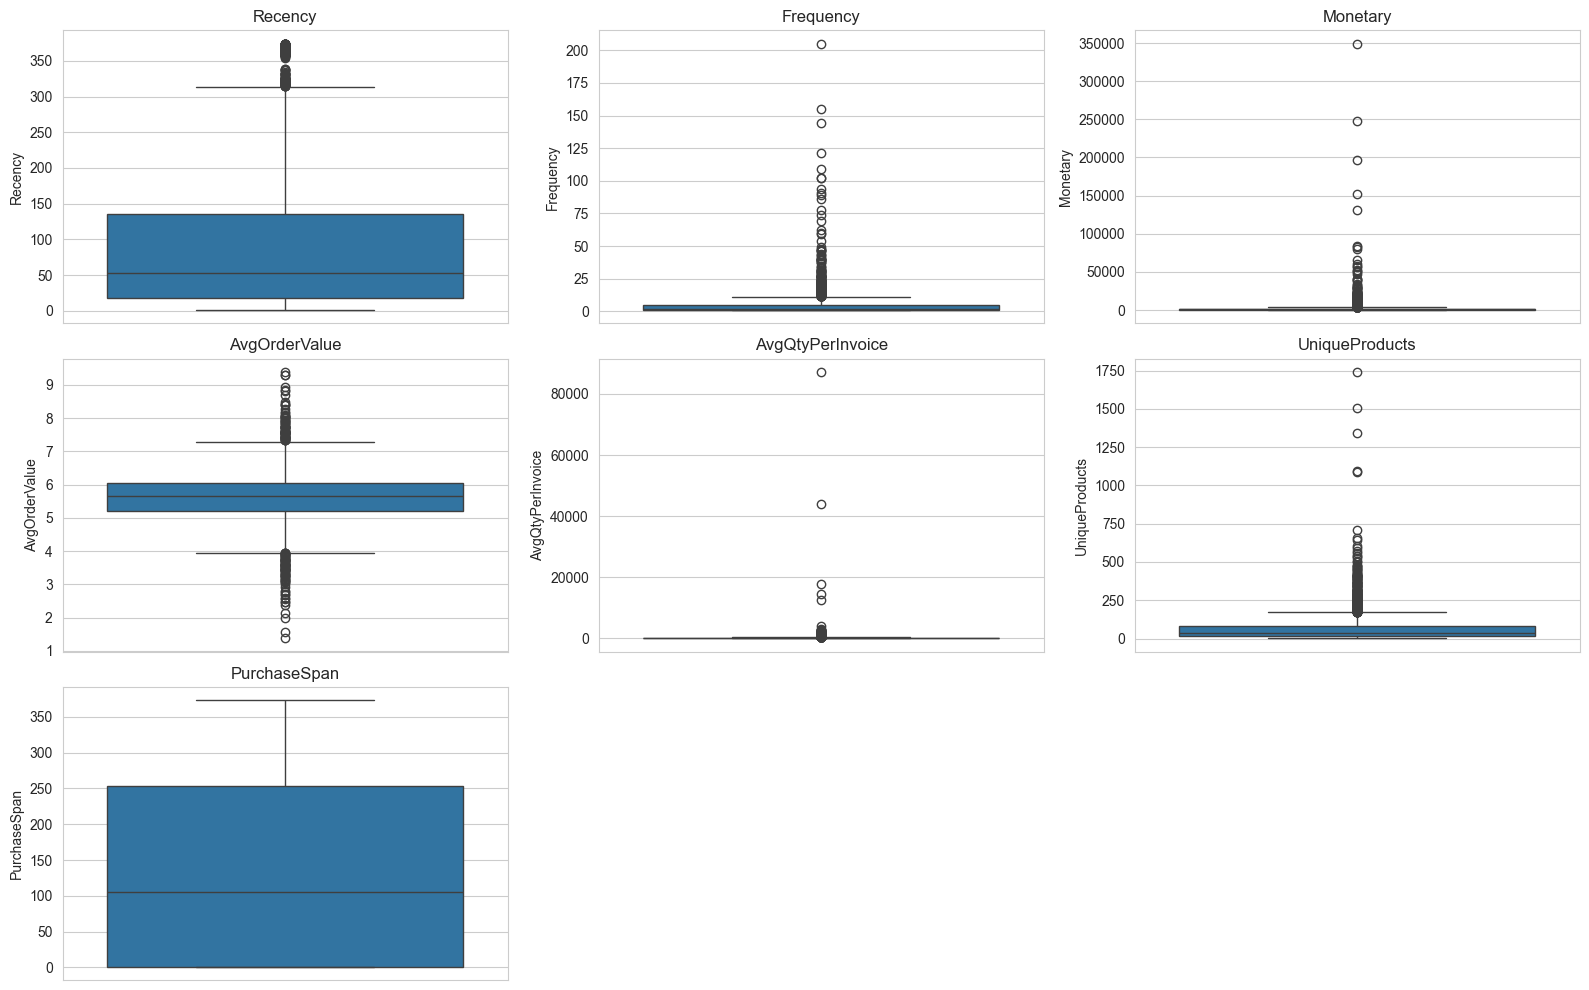

In [13]:

plt.figure(figsize=(16, 10))

for i, col in enumerate(features_to_plot, 1):
    plt.subplot(3, 3, i)
    sns.boxplot(y=customer_features[col])
    plt.title(col)

plt.tight_layout()

### Key Observations

- Monetary values are highly right-skewed, indicating that a small number of customers contribute a large portion of revenue.
- Frequency also shows skewness, with most customers making few purchases.
- Recency varies significantly, indicating differences in customer activity levels.
- Several features exhibit strong outliers, especially Monetary and AvgOrderValue.
- Positive correlation exists between Frequency and Monetary, suggesting that frequent customers tend to spend more.
- Temporal features such as PurchaseSpan and PurchaseRate capture long-term engagement behavior.

These observations justify the use of log transformation and scaling before clustering.

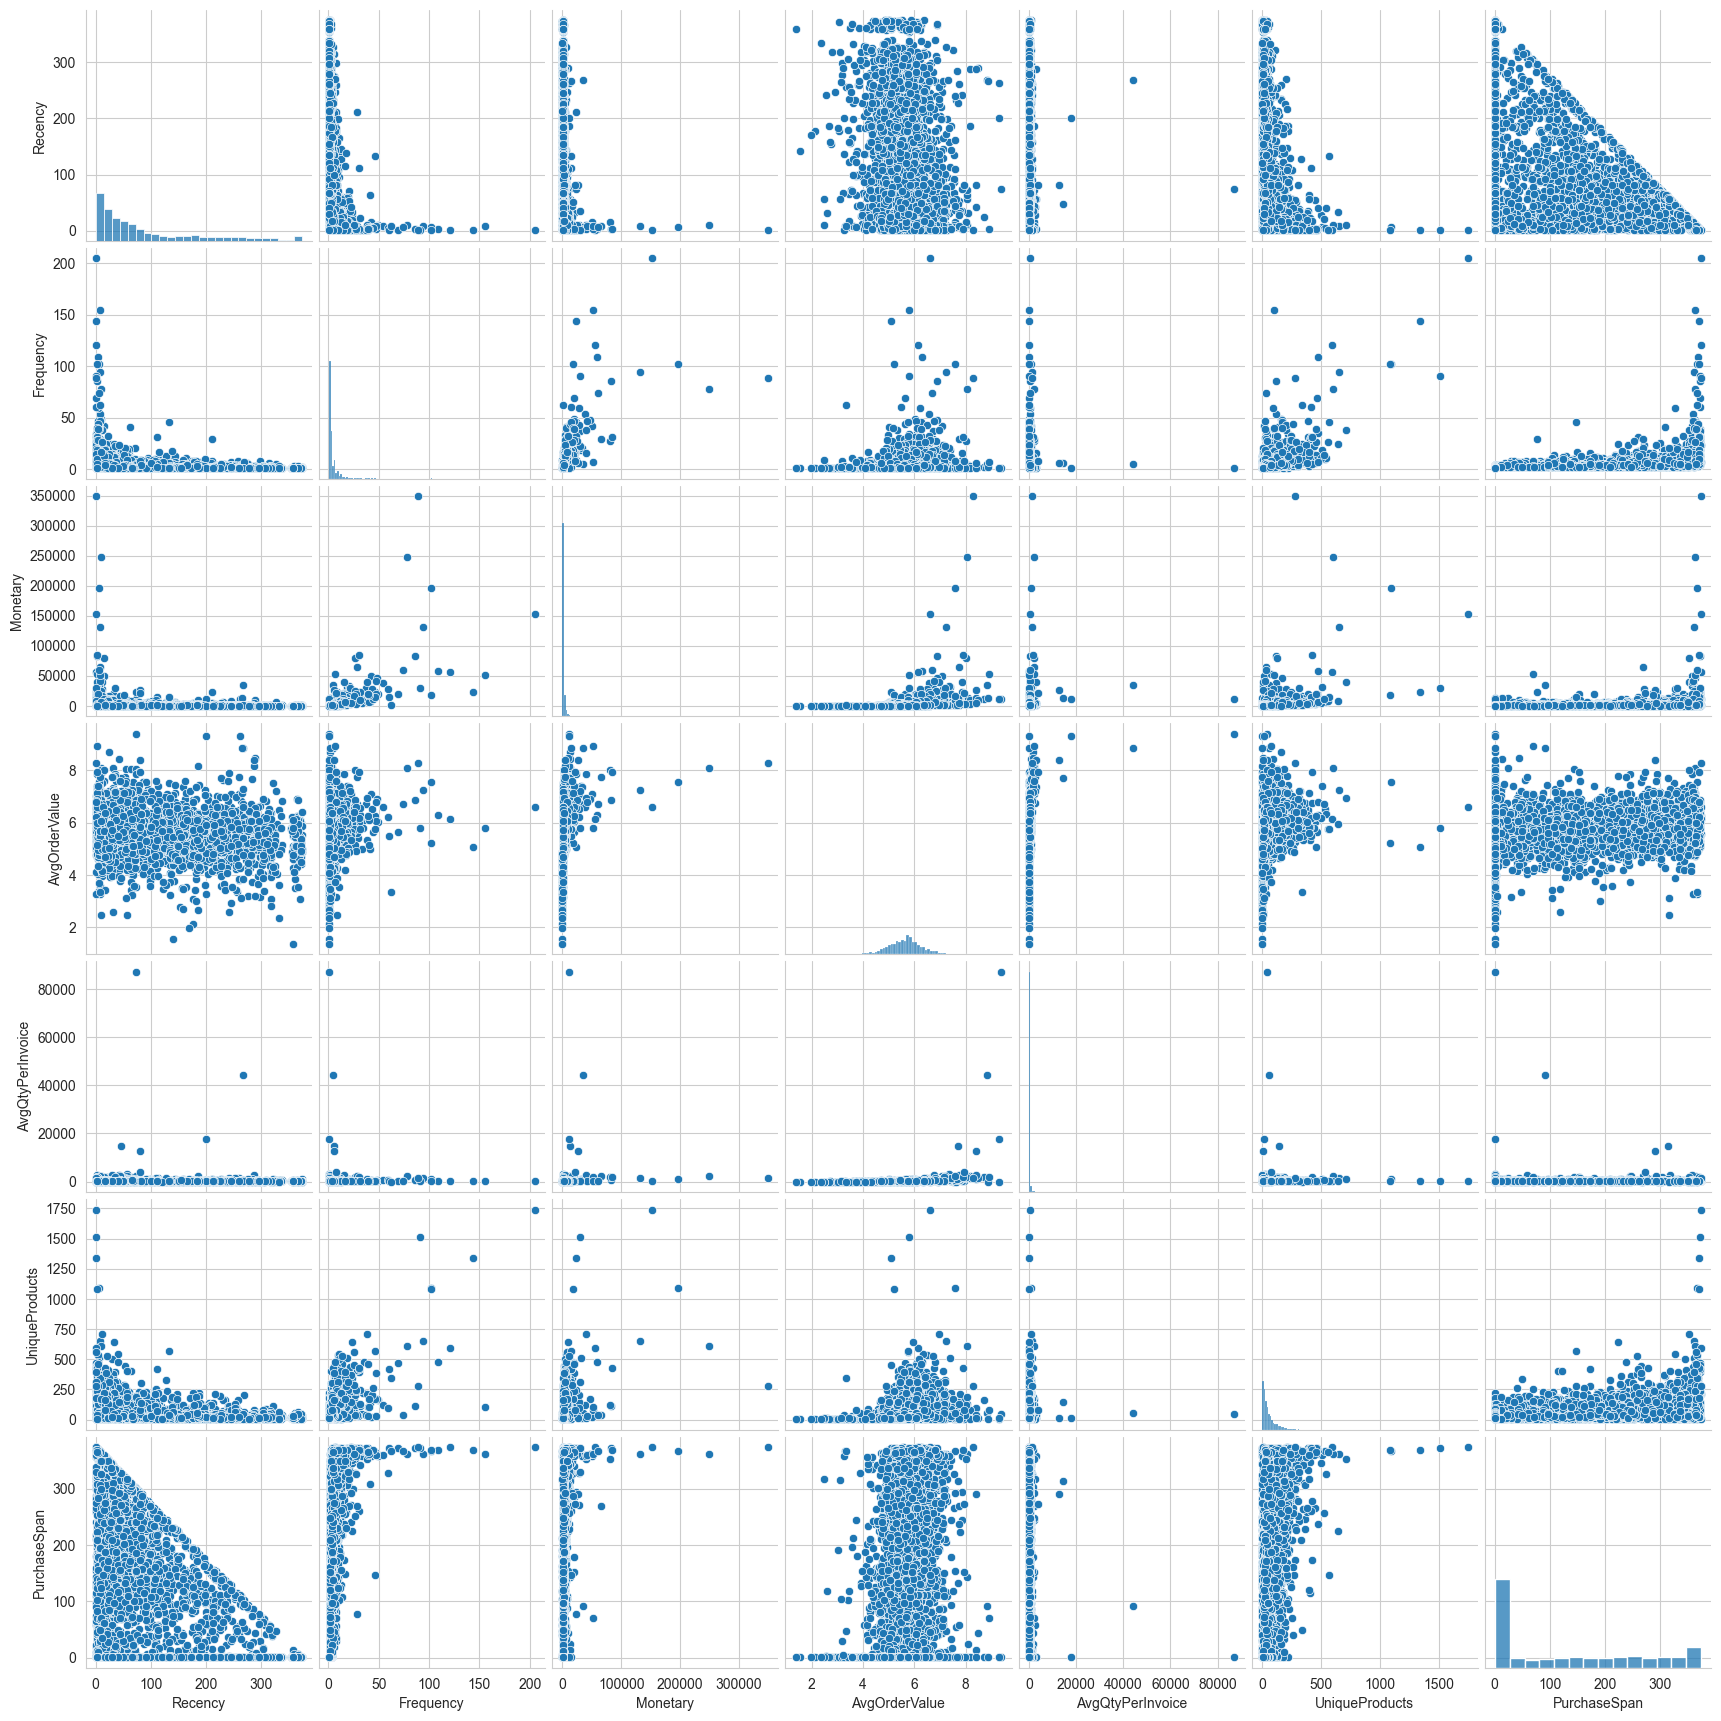

In [14]:
sns.pairplot(customer_features[features_to_plot])
plt.show()

## 9. Feature Set Construction

Two feature sets are constructed for comparison:

1. **Baseline (RFM Only)**:
   Includes Recency, Frequency, and Monetary features.

2. **Extended Feature Set**:
   Includes additional behavioral features such as AvgOrderValue, UniqueProducts, PurchaseSpan, PurchaseRate, and ActivityScore.

Redundant features were removed to reduce multicollinearity and improve clustering stability. The final feature set is designed to capture customer activity, value, and behavioral patterns.

In [15]:
# Baseline Feature Set (RFM only)
rfm_only = customer_features[
    [cust_col, "Recency", "Frequency", "Monetary"]
].copy()

# Final Selected Feature Set (curated for clustering)
selected_features = [
    "Recency",
    "Frequency",
    "Monetary",
    "AvgOrderValue",
    "UniqueProducts",
    "PurchaseSpan",
    "PurchaseRate",
    "ActivityScore"
]

extended = customer_features[[cust_col] + selected_features].copy()

print("RFM Features:")
display(rfm_only.head())

print("\nExtended Feature Set:")
display(extended.head())

RFM Features:


,Customer ID,Recency,Frequency,Monetary
0,12346.0,165,11,372.86
1,12347.0,3,2,1323.32
2,12348.0,74,1,222.16
3,12349.0,43,3,2671.14
4,12351.0,11,1,300.93



Extended Feature Set:


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseSpan,PurchaseRate,ActivityScore
0,12346.0,165,11,372.86,3.552383,26,196,0.056122,120.544
1,12347.0,3,2,1323.32,6.496262,70,37,0.054054,529.528
2,12348.0,74,1,222.16,5.407889,20,1,1.000000,74.464
3,12349.0,43,3,2671.14,6.792771,90,181,0.016575,1061.056
4,12351.0,11,1,300.93,5.710195,21,1,1.000000,118.572


In [16]:
# Check feature variance (important for clustering)
print("Feature Variance:")
print(extended.drop(columns=[cust_col]).var().sort_values(ascending=False))

Feature Variance:
Monetary          7.946798e+07
ActivityScore     1.274732e+07
PurchaseSpan      1.755022e+04
Recency           9.381982e+03
UniqueProducts    7.354429e+03
Frequency         6.675239e+01
AvgOrderValue     5.495710e-01
PurchaseRate      2.748671e-01
dtype: float64


## 10. Data Preprocessing

To ensure reliable clustering performance, several preprocessing steps are applied to the feature set:

1. **Outlier Handling**  
   Extreme values are capped using the Interquartile Range (IQR) method. This reduces the impact of outliers on distance-based clustering algorithms such as K-Means and DBSCAN.

2. **Log Transformation**  
   Since many features (e.g., Monetary and Frequency) are highly skewed, a logarithmic transformation is applied to normalize their distributions.

3. **Feature Selection (Variance Filtering)**  
   Features with zero or near-zero variance are removed to avoid redundancy and improve clustering stability.

4. **Feature Scaling**  
   All features are standardized using StandardScaler to ensure equal contribution during clustering, as clustering algorithms are sensitive to feature scale.

These preprocessing steps significantly improve clustering quality by stabilizing feature distributions and reducing noise.

In [17]:
def preprocess_features(df_features, id_col):
    data = df_features.copy()
    
    # Select feature columns (exclude ID)
    feature_cols = [c for c in data.columns if c != id_col]
    
    # 1. Outlier Capping (IQR method)
    for col in feature_cols:
        Q1 = data[col].quantile(0.25)
        Q3 = data[col].quantile(0.75)
        IQR = Q3 - Q1
        
        lower = Q1 - 1.5 * IQR
        upper = Q3 + 1.5 * IQR
        
        data[col] = np.clip(data[col], lower, upper)
    
    # 2. Safe Log Transformation
    data[feature_cols] = np.log1p(data[feature_cols].clip(lower=0))
    
    # 3. Remove Low-Variance Features
    variance = data[feature_cols].var()
    feature_cols = variance[variance > 0].index.tolist()
    
    # 4. Feature Scaling
    scaler = StandardScaler()
    scaled = scaler.fit_transform(data[feature_cols])
    
    return data, scaled, feature_cols

In [18]:
rfm_log, rfm_scaled, rfm_cols = preprocess_features(rfm_only, cust_col)
ext_log, ext_scaled, ext_cols = preprocess_features(extended, cust_col)

print("RFM scaled shape:", rfm_scaled.shape)
print("Extended scaled shape:", ext_scaled.shape)

RFM scaled shape: (4312, 3)
Extended scaled shape: (4312, 8)


In [19]:
print("Selected Features (Extended):")
print(ext_cols)

Selected Features (Extended):
['Recency', 'Frequency', 'Monetary', 'AvgOrderValue', 'UniqueProducts', 'PurchaseSpan', 'PurchaseRate', 'ActivityScore']


## 11. Elbow Method and Cluster Selection (Enhanced)

To determine the optimal number of clusters, we apply the Elbow Method combined with Silhouette Score analysis.

- **Inertia (Elbow Curve)** measures within-cluster variance. A sharp decrease followed by a plateau suggests an optimal number of clusters.
- **Silhouette Score** evaluates how well-separated the clusters are. Higher values indicate better-defined clusters.

By analyzing both metrics, we select a value of K that balances cluster compactness and separation.

This combined approach provides a more reliable estimate compared to using the elbow method alone.

In [20]:
def plot_elbow(X, title):
    inertia = []
    silhouette_scores = []
    k_range = range(2, 11)

    for k in k_range:
        km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
        labels = km.fit_predict(X)
        
        inertia.append(km.inertia_)
        
        # Safe silhouette calculation
        if len(set(labels)) > 1:
            score = silhouette_score(X, labels)
        else:
            score = np.nan
        
        silhouette_scores.append(score)

    # Plot
    plt.figure(figsize=(12, 4))

    plt.subplot(1, 2, 1)
    plt.plot(k_range, inertia, marker="o")
    plt.title(f"{title} - Inertia")

    plt.subplot(1, 2, 2)
    plt.plot(k_range, silhouette_scores, marker="o", color="green")
    plt.title(f"{title} - Silhouette")

    plt.tight_layout()
    plt.show()

    # Safe best K
    valid_scores = [
        (k, score) for k, score in zip(k_range, silhouette_scores)
        if not np.isnan(score)
    ]

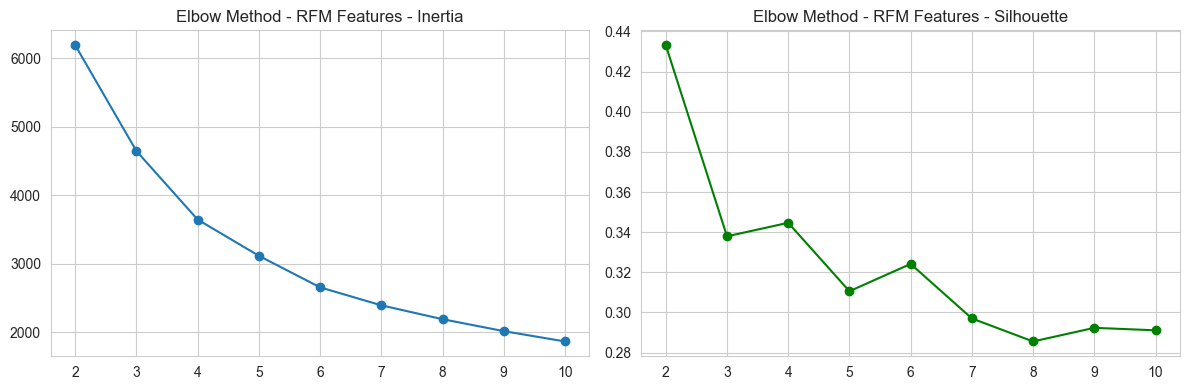

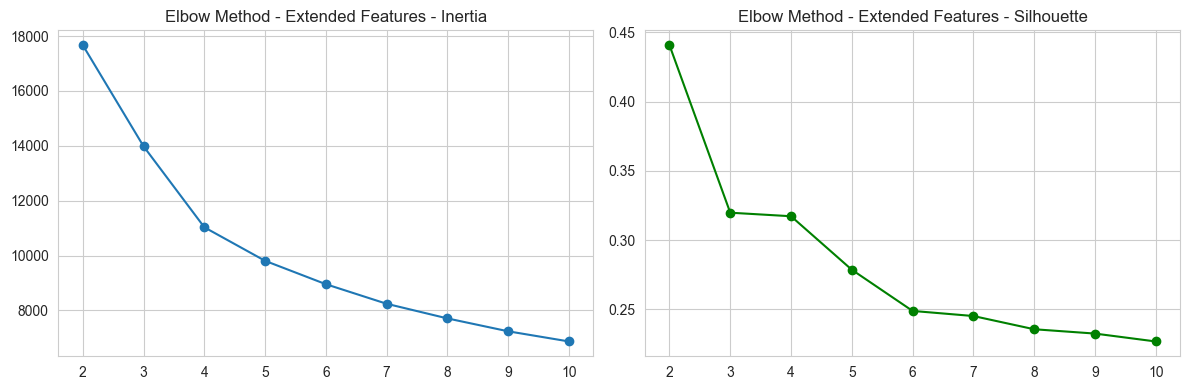

In [21]:
plot_elbow(rfm_scaled, "Elbow Method - RFM Features")
plot_elbow(ext_scaled, "Elbow Method - Extended Features")

## 12. Hierarchical Clustering

Hierarchical clustering is used to analyze the structure of the dataset and identify potential cluster groupings.

A dendrogram is generated using Ward linkage, which minimizes within-cluster variance.

Since hierarchical clustering is computationally expensive, a subset of the data is used for visualization.

In addition to the dendrogram, we evaluate clustering performance across different numbers of clusters using the silhouette score.

This combined approach provides:
- Visual insight into cluster structure
- Quantitative evaluation of cluster quality

The optimal number of clusters is selected based on silhouette score trends.

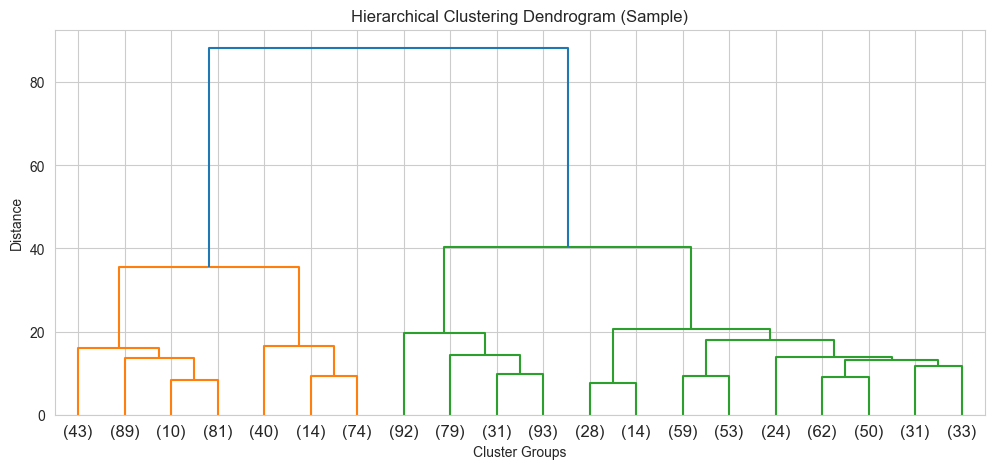

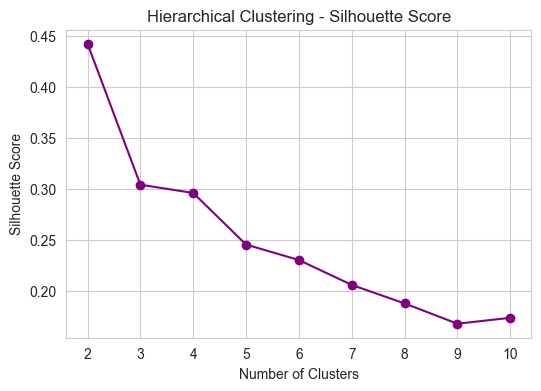

Suggested optimal number of clusters: 2


In [22]:
# Step 1: Sample data (for performance)
sample_size = min(1000, ext_scaled.shape[0])
sample_indices = np.random.RandomState(RANDOM_STATE).choice(
    ext_scaled.shape[0], sample_size, replace=False
)
ext_sample = ext_scaled[sample_indices]

# Step 2: Linkage matrix
linked = linkage(ext_sample, method="ward")

# Step 3: Plot dendrogram
plt.figure(figsize=(12, 5))
dendrogram(linked, truncate_mode="lastp", p=20)
plt.title("Hierarchical Clustering Dendrogram (Sample)")
plt.xlabel("Cluster Groups")
plt.ylabel("Distance")
plt.show()


# Step 4: Evaluate Different Cluster Sizes
cluster_range = range(2, 11)
silhouette_scores = []

for k in cluster_range:
    model = AgglomerativeClustering(n_clusters=k, linkage="ward")
    labels = model.fit_predict(ext_scaled)

    if len(set(labels)) > 1:
        score = silhouette_score(ext_scaled, labels)
    else:
        score = np.nan

    silhouette_scores.append(score)

# Plot silhouette scores
plt.figure(figsize=(6, 4))
plt.plot(cluster_range, silhouette_scores, marker="o", color="purple")
plt.title("Hierarchical Clustering - Silhouette Score")
plt.xlabel("Number of Clusters")
plt.ylabel("Silhouette Score")
plt.show()


# Step 5: Best Cluster Selection
valid_scores = [
    (k, score) for k, score in zip(cluster_range, silhouette_scores)
    if not np.isnan(score)
]

if valid_scores:
    best_k = max(valid_scores, key=lambda x: x[1])[0]
    print(f"Suggested optimal number of clusters: {best_k}")
else:
    print("Could not determine optimal cluster count")

## 13. Clustering Evaluation Metrics

To evaluate clustering performance, we use multiple metrics:

- **Silhouette Score**: Measures how well-separated clusters are. Higher values indicate better separation.
- **Davies-Bouldin Index**: Measures cluster compactness. Lower values indicate better clustering.
- **Calinski-Harabasz Score**: Evaluates the ratio of between-cluster variance to within-cluster variance. Higher values indicate better-defined clusters.

For density-based clustering (DBSCAN), noise points (labeled as -1) are excluded from evaluation.

Additionally, we report:
- Number of clusters detected
- Number of noise points

This multi-metric evaluation provides a more comprehensive assessment of clustering performance.

In [23]:
def evaluate_clustering(X, labels):
    
    unique_labels = set(labels)
    
    # Count clusters (excluding noise)
    num_clusters = len(unique_labels - {-1})
    
    # Count noise points (for DBSCAN)
    num_noise = int(np.sum(labels == -1)) if -1 in labels else 0
    
    # If less than 2 clusters → cannot evaluate
    if num_clusters < 2:
        return {
            "Clusters": num_clusters,
            "NoisePoints": num_noise,
            "Silhouette": np.nan,
            "DaviesBouldin": np.nan,
            "CalinskiHarabasz": np.nan
        }
    
    # Remove noise points for evaluation (DBSCAN case)
    if -1 in unique_labels:
        mask = labels != -1
        X_eval = X[mask]
        labels_eval = labels[mask]
    else:
        X_eval = X
        labels_eval = labels
    
    # Final safety check
    if len(set(labels_eval)) < 2:
        return {
            "Clusters": num_clusters,
            "NoisePoints": num_noise,
            "Silhouette": np.nan,
            "DaviesBouldin": np.nan,
            "CalinskiHarabasz": np.nan
        }
    
    # Compute metrics
    silhouette = silhouette_score(X_eval, labels_eval)
    db_index = davies_bouldin_score(X_eval, labels_eval)
    ch_score = calinski_harabasz_score(X_eval, labels_eval)
    
    return {
        "Clusters": num_clusters,
        "NoisePoints": num_noise,
        "Silhouette": silhouette,
        "DaviesBouldin": db_index,
        "CalinskiHarabasz": ch_score
    }

# -----------------------------
# Generate Cluster Labels (ALL MODELS)
# -----------------------------

# KMeans on RFM
kmeans_rfm = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_rfm = kmeans_rfm.fit_predict(rfm_scaled)

# KMeans on Extended Features
kmeans_ext = KMeans(n_clusters=4, random_state=RANDOM_STATE, n_init=10)
labels_kmeans_ext = kmeans_ext.fit_predict(ext_scaled)

# Hierarchical Clustering
agg_ext = AgglomerativeClustering(n_clusters=4, linkage="ward")
labels_agg_ext = agg_ext.fit_predict(ext_scaled)

# DBSCAN
dbscan_ext = DBSCAN(eps=0.8, min_samples=10)
labels_dbscan_ext = dbscan_ext.fit_predict(ext_scaled)

# Run Evaluation for All Models

metrics_kmeans_rfm = evaluate_clustering(rfm_scaled, labels_kmeans_rfm)
metrics_kmeans_ext = evaluate_clustering(ext_scaled, labels_kmeans_ext)
metrics_hier = evaluate_clustering(ext_scaled, labels_agg_ext)
metrics_dbscan = evaluate_clustering(ext_scaled, labels_dbscan_ext)

# Pretty Output

print("\n=== MODEL COMPARISON ===\n")

for _, row in results.iterrows():
    print(f"Method: {row['Method']} ({row['FeatureSet']})")
    print(f"Clusters: {row['Clusters']}")
    print(f"Noise Points: {row['NoisePoints']}")
    print(f"Silhouette: {row['Silhouette']:.4f}")
    print(f"Davies-Bouldin: {row['DaviesBouldin']:.4f}")
    print(f"Calinski-Harabasz: {row['CalinskiHarabasz']:.2f}")
    print("-" * 40)


=== MODEL COMPARISON ===



NameError: name 'results' is not defined

## 14. Model 1 - K-Means on RFM (Baseline)
This model serves as the baseline approach using traditional RFM features.

KMeans is a centroid-based clustering algorithm that partitions customers into clusters by minimizing within-cluster variance.

This baseline model is used to evaluate the effectiveness of additional features and alternative clustering methods introduced in this study.

The results from this model provide a reference point for comparison against more advanced approaches.


=== Model 1: KMeans (RFM Features) ===
Method: KMeans
FeatureSet: RFM
Clusters: 4
NoisePoints: 0
Silhouette: 0.3447
DaviesBouldin: 1.0034
CalinskiHarabasz: 3659.8358


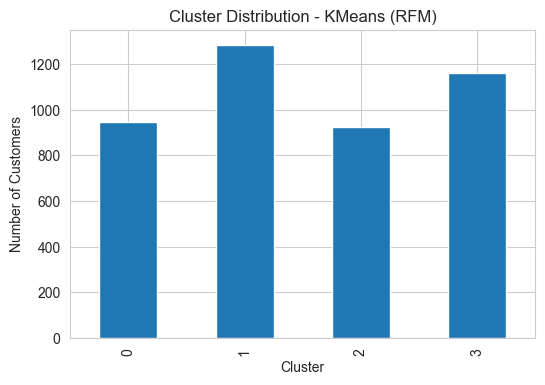

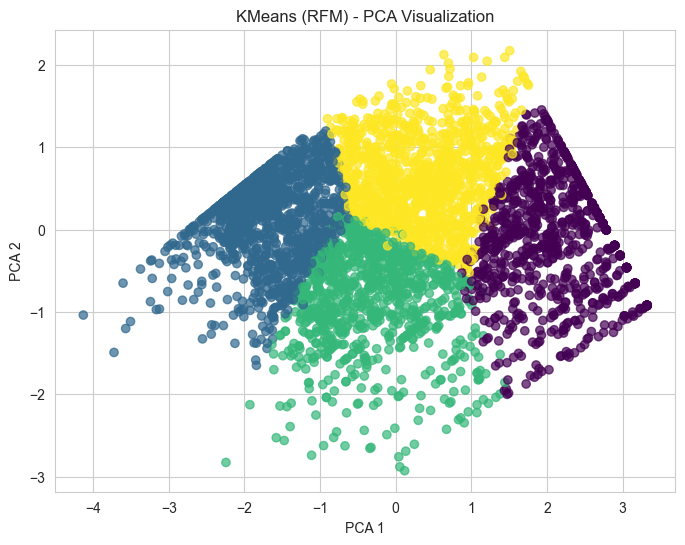

In [ ]:
# Step 1: Train model
kmeans_rfm = KMeans(
    n_clusters=4,
    random_state=RANDOM_STATE,
    n_init=10
)

labels_kmeans_rfm = kmeans_rfm.fit_predict(rfm_scaled)


# Step 2: Evaluate model
metrics_kmeans_rfm = evaluate_clustering(rfm_scaled, labels_kmeans_rfm)


# Step 3: Display results (structured)
model1_results = {
    "Method": "KMeans",
    "FeatureSet": "RFM",
    **metrics_kmeans_rfm
}

print("\n=== Model 1: KMeans (RFM Features) ===")
for key, value in model1_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


# Step 4: Cluster distribution
plt.figure(figsize=(6,4))
pd.Series(labels_kmeans_rfm).value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Distribution - KMeans (RFM)")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


# Step 5: PCA visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_data = pca.fit_transform(rfm_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=labels_kmeans_rfm, cmap="viridis", alpha=0.7)
plt.title("KMeans (RFM) - PCA Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## 15. Model 2 - K-Means on Extended Features

This model extends the baseline KMeans approach by incorporating additional behavioral features beyond the traditional RFM representation.

The extended feature set includes metrics such as average order value, product diversity, and temporal behavior, which aim to capture more complex customer patterns.

This model allows us to evaluate whether additional features improve clustering performance compared to the baseline RFM model.

The results are compared with other models to assess improvements in cluster separation and overall segmentation quality.


=== Model 2: KMeans (Extended Features) ===
Method: KMeans
FeatureSet: Extended
Clusters: 4
NoisePoints: 0
Silhouette: 0.3173
DaviesBouldin: 1.1476
CalinskiHarabasz: 3055.2417


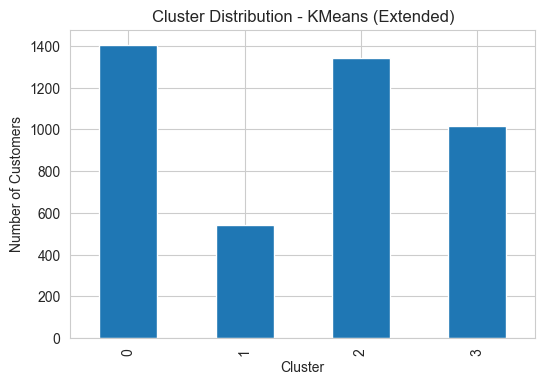

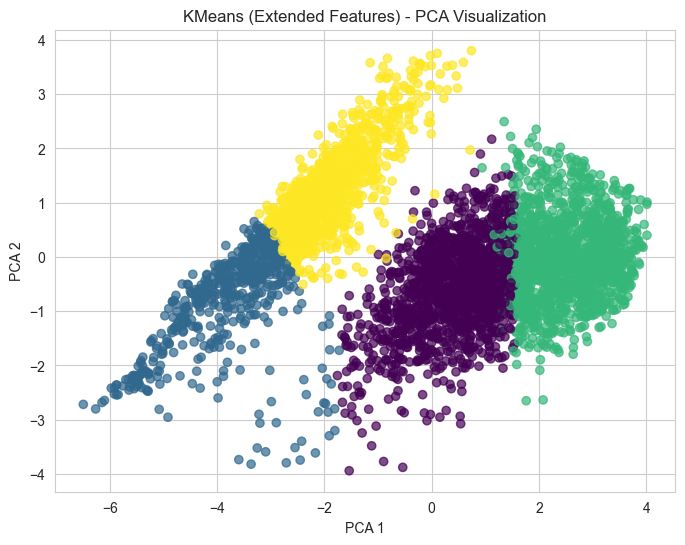

In [ ]:
# Step 1: Train model
kmeans_ext = KMeans(
    n_clusters=4,
    random_state=RANDOM_STATE,
    n_init=10
)

labels_kmeans_ext = kmeans_ext.fit_predict(ext_scaled)


# Step 2: Evaluate model
metrics_kmeans_ext = evaluate_clustering(ext_scaled, labels_kmeans_ext)


# Step 3: Display results (structured)
model2_results = {
    "Method": "KMeans",
    "FeatureSet": "Extended",
    **metrics_kmeans_ext
}

print("\n=== Model 2: KMeans (Extended Features) ===")
for key, value in model2_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


# Step 4: Cluster distribution
plt.figure(figsize=(6,4))
pd.Series(labels_kmeans_ext).value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Distribution - KMeans (Extended)")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


# Step 5: PCA visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_data = pca.fit_transform(ext_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=labels_kmeans_ext, cmap="viridis", alpha=0.7)
plt.title("KMeans (Extended Features) - PCA Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## 16. Model 3 - Hierarchical Clustering on Extended Features

Hierarchical clustering is applied to the extended feature set to explore the structure of customer relationships.

Unlike KMeans, hierarchical clustering does not rely on predefined cluster centroids. Instead, it builds a hierarchy of clusters based on pairwise distances.

We use Ward linkage, which minimizes within-cluster variance and produces compact clusters.

This model provides an alternative perspective on customer segmentation and allows us to compare centroid-based and hierarchical approaches.


=== Model 3: Hierarchical Clustering (Extended Features) ===
Method: Hierarchical
FeatureSet: Extended
Clusters: 4
NoisePoints: 0
Silhouette: 0.2959
DaviesBouldin: 1.1821
CalinskiHarabasz: 2882.5907


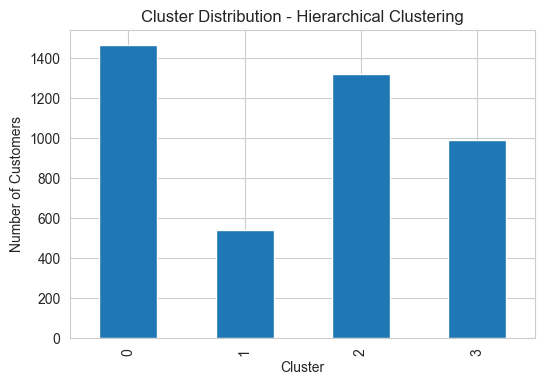

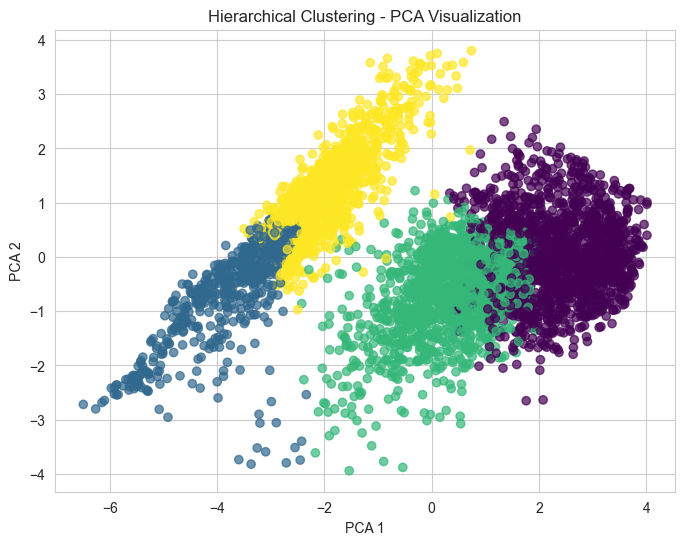

In [ ]:
# Step 1: Train model
agg_ext = AgglomerativeClustering(
    n_clusters=4,
    linkage="ward"
)

labels_agg_ext = agg_ext.fit_predict(ext_scaled)


# Step 2: Evaluate model
metrics_agg_ext = evaluate_clustering(ext_scaled, labels_agg_ext)


# Step 3: Display results (structured)
model3_results = {
    "Method": "Hierarchical",
    "FeatureSet": "Extended",
    **metrics_agg_ext
}

print("\n=== Model 3: Hierarchical Clustering (Extended Features) ===")
for key, value in model3_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


# Step 4: Cluster distribution
plt.figure(figsize=(6,4))
pd.Series(labels_agg_ext).value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Distribution - Hierarchical Clustering")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


# Step 5: PCA visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_data = pca.fit_transform(ext_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=labels_agg_ext, cmap="viridis", alpha=0.7)
plt.title("Hierarchical Clustering - PCA Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

## 17. Model 4 - DBSCAN on Extended Features

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is applied to the extended feature set.

Unlike KMeans and Hierarchical clustering, DBSCAN:
- Does not require specifying the number of clusters in advance
- Groups data points based on density
- Identifies noise points (outliers) automatically

This makes DBSCAN particularly suitable for real-world datasets with irregular structures and outliers.

In this study, DBSCAN is used to:
- Detect natural clusters
- Identify unusual customer behavior
- Improve cluster separation compared to centroid-based methods


=== Model 4: DBSCAN (Extended Features) ===
Method: DBSCAN
FeatureSet: Extended
Clusters: 2
NoisePoints: 364
Silhouette: 0.4759
DaviesBouldin: 0.8374
CalinskiHarabasz: 4318.9484


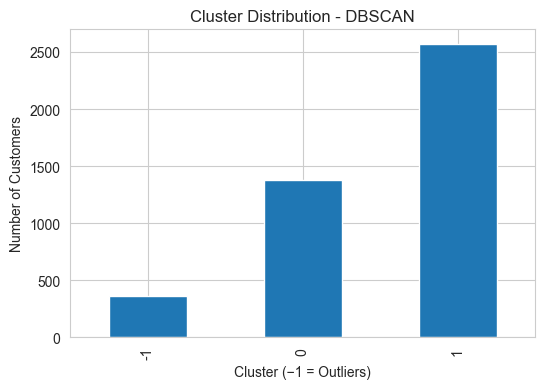

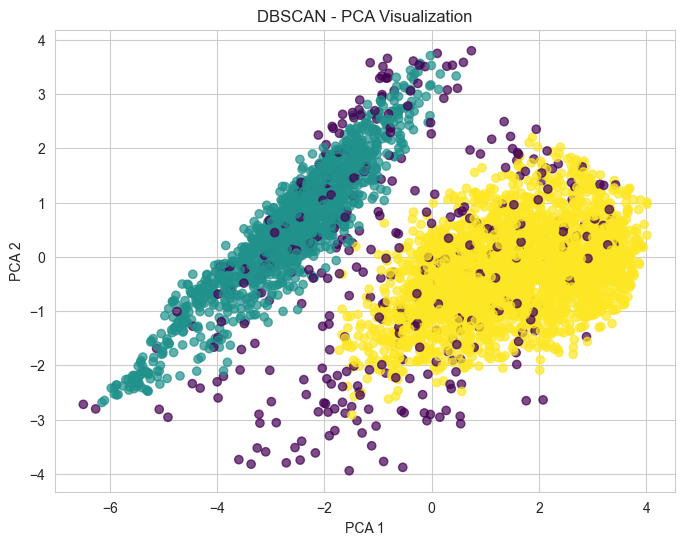


Noise Points: 364 (8.44%)


In [ ]:
# Step 1: Train model
dbscan_ext = DBSCAN(
    eps=0.8,
    min_samples=10
)

labels_dbscan_ext = dbscan_ext.fit_predict(ext_scaled)


# Step 2: Evaluate model
metrics_dbscan_ext = evaluate_clustering(ext_scaled, labels_dbscan_ext)


# Step 3: Display results (structured)
model4_results = {
    "Method": "DBSCAN",
    "FeatureSet": "Extended",
    **metrics_dbscan_ext
}

print("\n=== Model 4: DBSCAN (Extended Features) ===")
for key, value in model4_results.items():
    if isinstance(value, float):
        print(f"{key}: {value:.4f}")
    else:
        print(f"{key}: {value}")


# Step 4: Cluster distribution (including noise)
plt.figure(figsize=(6,4))
pd.Series(labels_dbscan_ext).value_counts().sort_index().plot(kind="bar")
plt.title("Cluster Distribution - DBSCAN")
plt.xlabel("Cluster (−1 = Outliers)")
plt.ylabel("Number of Customers")
plt.show()


# Step 5: PCA visualization
pca = PCA(n_components=2, random_state=RANDOM_STATE)
pca_data = pca.fit_transform(ext_scaled)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=labels_dbscan_ext, cmap="viridis", alpha=0.7)
plt.title("DBSCAN - PCA Visualization")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()


# Step 6: Noise analysis
noise_points = np.sum(labels_dbscan_ext == -1)
total_points = len(labels_dbscan_ext)

print(f"\nNoise Points: {noise_points} ({(noise_points/total_points)*100:.2f}%)")

## 18. Model Comparison

We compare multiple clustering methods using different evaluation metrics:

- Silhouette Score → cluster separation
- Davies-Bouldin Index → cluster compactness
- Calinski-Harabasz Score → cluster quality

This multi-metric comparison provides a comprehensive evaluation of clustering performance.

In [ ]:
# -----------------------------
# Final Model Comparison Table
# -----------------------------

results = pd.DataFrame([
    {"Method": "KMeans", "FeatureSet": "RFM", **metrics_kmeans_rfm},
    {"Method": "KMeans", "FeatureSet": "Extended", **metrics_kmeans_ext},
    {"Method": "Hierarchical", "FeatureSet": "Extended", **metrics_agg_ext},
    {"Method": "DBSCAN", "FeatureSet": "Extended", **metrics_dbscan_ext}
])

# Clean display
results = results[[
    "Method", "FeatureSet", "Clusters", "NoisePoints",
    "Silhouette", "DaviesBouldin", "CalinskiHarabasz"
]]

display(results)

,Method,FeatureSet,Clusters,NoisePoints,Silhouette,DaviesBouldin,CalinskiHarabasz
0,KMeans,RFM,4,0,0.344684,1.003413,3659.835761
1,KMeans,Extended,4,0,0.317289,1.147639,3055.241684
2,Hierarchical,Extended,4,0,0.295943,1.182141,2882.590670
3,DBSCAN,Extended,2,364,0.475855,0.837350,4318.948416


# Visualize comparison

## A. Silhouette Score Comparison

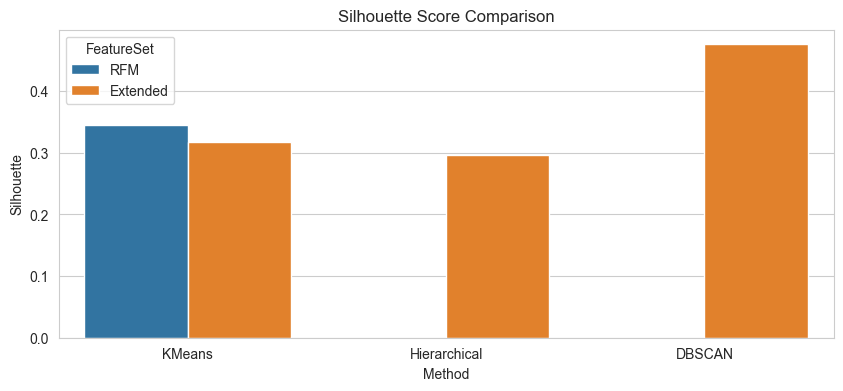

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(data=results, x="Method", y="Silhouette", hue="FeatureSet")
plt.title("Silhouette Score Comparison")
plt.show()

## B. Davies-Bouldin Index

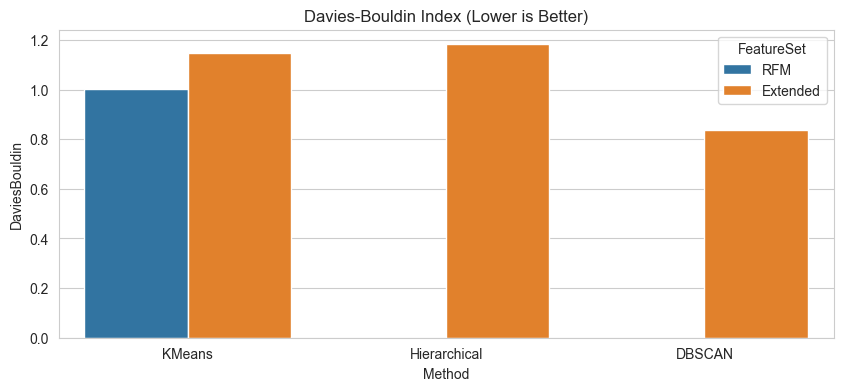

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(data=results, x="Method", y="DaviesBouldin", hue="FeatureSet")
plt.title("Davies-Bouldin Index (Lower is Better)")
plt.show()

## C. Calinski-Harabasz Score

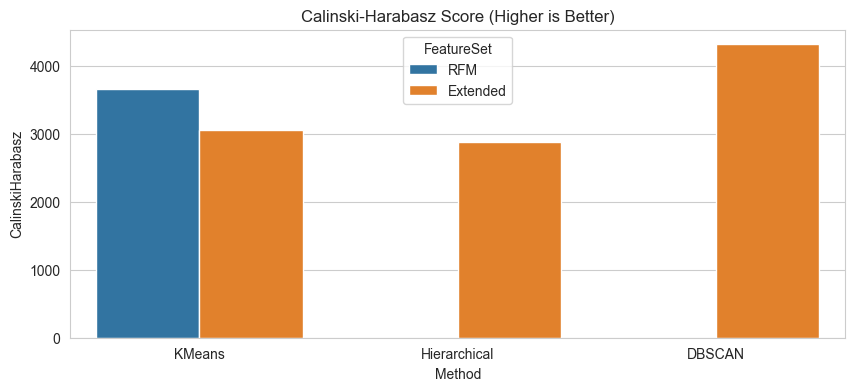

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(data=results, x="Method", y="CalinskiHarabasz", hue="FeatureSet")
plt.title("Calinski-Harabasz Score (Higher is Better)")
plt.show()

## D. Cluster Count & Noise

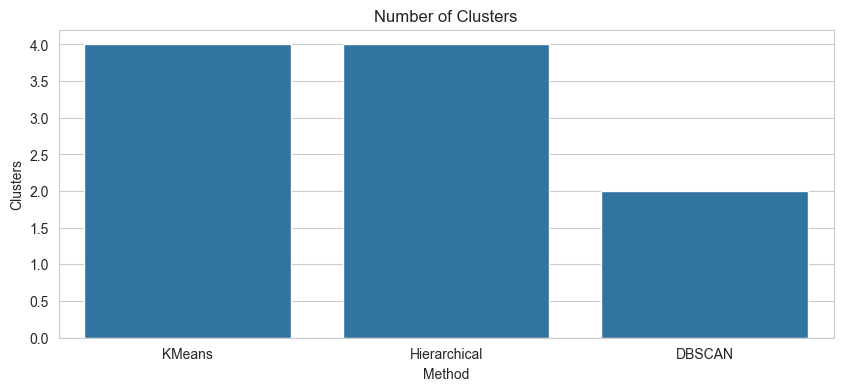

In [ ]:
plt.figure(figsize=(10,4))
sns.barplot(data=results, x="Method", y="Clusters")
plt.title("Number of Clusters")
plt.show()

## Best Model Selection

Among the evaluated models, DBSCAN with the extended feature set achieved the highest silhouette score, indicating superior cluster separation.

Unlike KMeans and hierarchical clustering, DBSCAN does not assume spherical clusters and can detect clusters of arbitrary shapes. Additionally, it identifies noise points (outliers), which represent unusual customer behavior that other methods force into clusters.

Although KMeans performed better in terms of Davies-Bouldin and Calinski-Harabasz scores, it assumes uniform cluster shapes and cannot explicitly detect outliers.

This highlights a trade-off:
- KMeans → better compactness
- DBSCAN → better separation and realism

Given the goal of identifying meaningful customer segments and detecting irregular behavior, DBSCAN is selected as the best-performing model.

This model provides more realistic segmentation for real-world customer behavior.

These results demonstrate that feature engineering combined with density-based clustering significantly improves customer segmentation quality.

## 19. Metric Visualization

We visualize evaluation metrics across models using bar charts.

This makes it easier to compare:
- Cluster separation
- Cluster compactness
- Overall performance

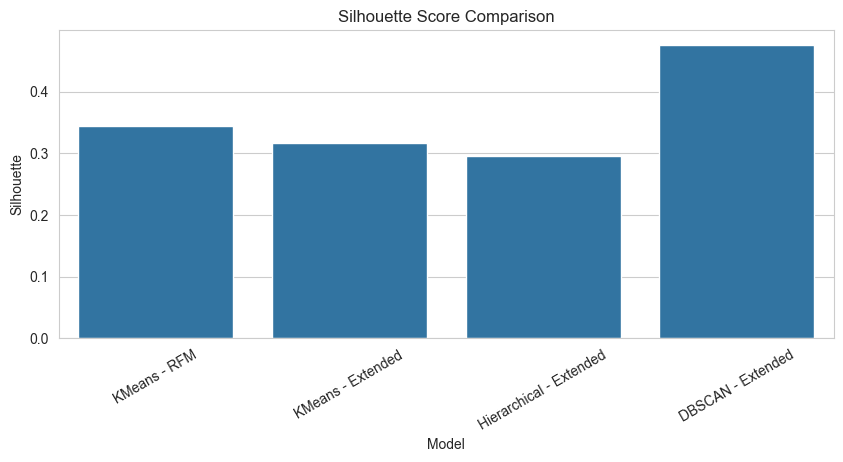

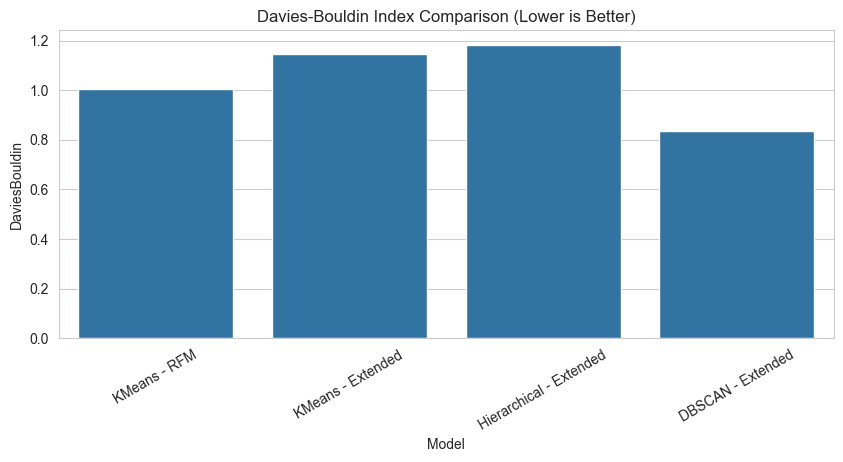

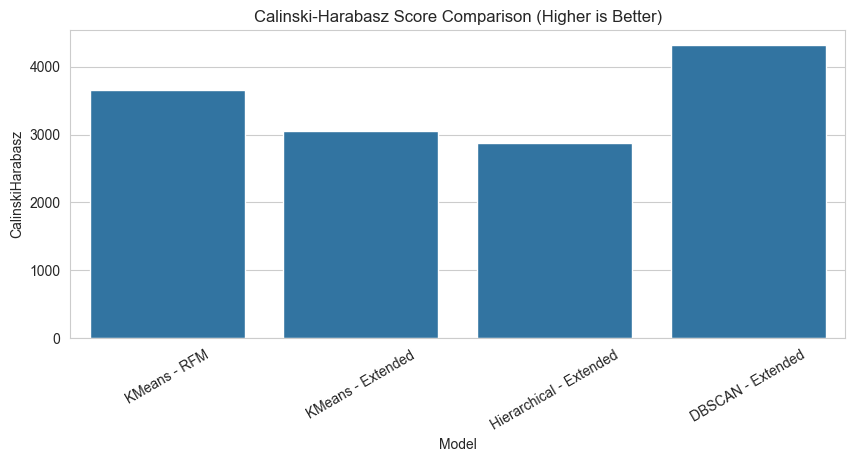

In [ ]:
plot_results = results.copy()
plot_results["Model"] = plot_results["Method"] + " - " + plot_results["FeatureSet"]

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_results, x="Model", y="Silhouette")
plt.title("Silhouette Score Comparison")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_results, x="Model", y="DaviesBouldin")
plt.title("Davies-Bouldin Index Comparison (Lower is Better)")
plt.xticks(rotation=30)
plt.show()

plt.figure(figsize=(10, 4))
sns.barplot(data=plot_results, x="Model", y="CalinskiHarabasz")
plt.title("Calinski-Harabasz Score Comparison (Higher is Better)")
plt.xticks(rotation=30)
plt.show()


## 20. PCA Visualization Function

We reduce feature dimensions using PCA and visualize clusters in 2D space.

This helps:
- Observe cluster separation
- Compare clustering methods visually


In [ ]:
def plot_pca_clusters(X, labels, title):
    pca = PCA(n_components=2, random_state=RANDOM_STATE)
    pca_data = pca.fit_transform(X)

    plt.figure(figsize=(8, 6))
    plt.scatter(pca_data[:, 0], pca_data[:, 1], c=labels, alpha=0.7)
    plt.title(title)
    plt.xlabel("PCA 1")
    plt.ylabel("PCA 2")
    plt.show()


## 21. PCA Projections of All Models


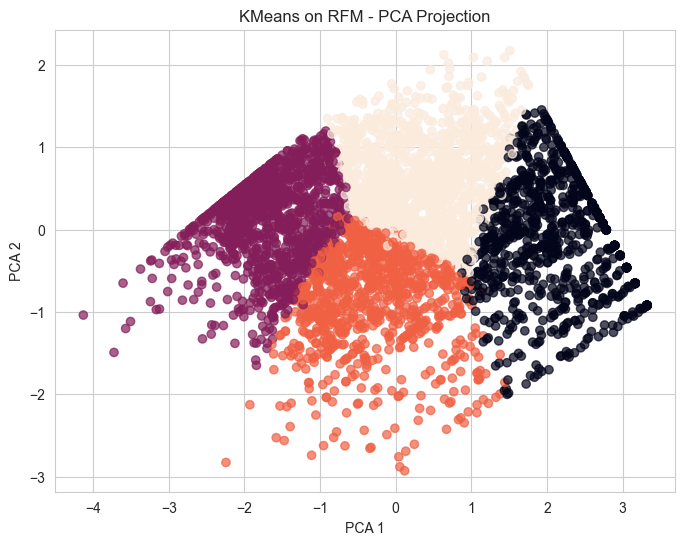

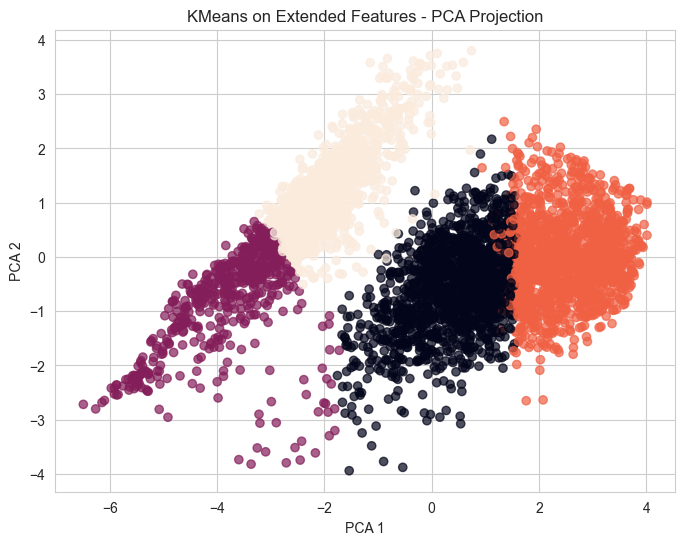

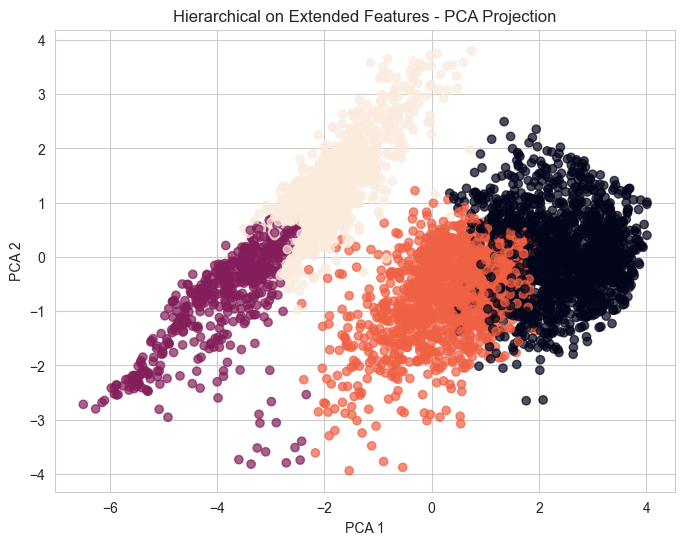

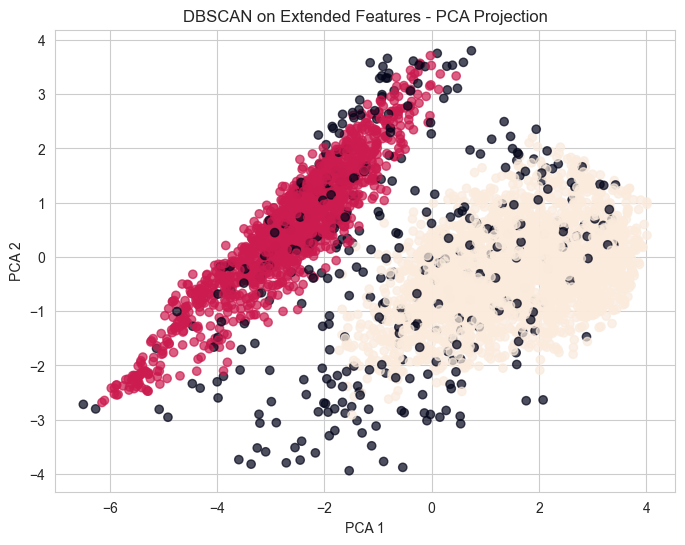

In [ ]:
plot_pca_clusters(rfm_scaled, labels_kmeans_rfm, "KMeans on RFM - PCA Projection")
plot_pca_clusters(ext_scaled, labels_kmeans_ext, "KMeans on Extended Features - PCA Projection")
plot_pca_clusters(ext_scaled, labels_agg_ext, "Hierarchical on Extended Features - PCA Projection")
plot_pca_clusters(ext_scaled, labels_dbscan_ext, "DBSCAN on Extended Features - PCA Projection")


## 22. Choose the Best Model

We choose the model with the highest valid silhouette score as a simple rule for the final model selection.

We select the best model based on evaluation metrics, primarily silhouette score.

The selected model is used for final segmentation and analysis

In [ ]:
valid_results = results.dropna(subset=["Silhouette"]).copy()
best_row = valid_results.sort_values("Silhouette", ascending=False).iloc[0]
best_row


Method                   DBSCAN
FeatureSet             Extended
ClustersFound                 2
NoisePoints                 364
Silhouette             0.475855
DaviesBouldin           0.83735
CalinskiHarabasz    4318.948416
Name: 3, dtype: object

## 23. Attach Best Labels to the Corresponding Dataset


In [ ]:
best_method = best_row["Method"]
best_featureset = best_row["FeatureSet"]

if best_method == "KMeans" and best_featureset == "RFM":
    best_labels = labels_kmeans_rfm
    best_feature_data = rfm_only.copy()
    best_scaled = rfm_scaled
elif best_method == "KMeans" and best_featureset == "Extended":
    best_labels = labels_kmeans_ext
    best_feature_data = extended.copy()
    best_scaled = ext_scaled
elif best_method == "Hierarchical":
    best_labels = labels_agg_ext
    best_feature_data = extended.copy()
    best_scaled = ext_scaled
else:
    best_labels = labels_dbscan_ext
    best_feature_data = extended.copy()
    best_scaled = ext_scaled

best_feature_data["Cluster"] = best_labels
best_feature_data.head()


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseSpan,PurchaseRate,ActivityScore,Cluster
0,12346.0,165,11,372.86,3.552383,26,196,0.056122,120.544,-1
1,12347.0,3,2,1323.32,6.496262,70,37,0.054054,529.528,-1
2,12348.0,74,1,222.16,5.407889,20,1,1.000000,74.464,0
3,12349.0,43,3,2671.14,6.792771,90,181,0.016575,1061.056,1
4,12351.0,11,1,300.93,5.710195,21,1,1.000000,118.572,0


## 24. Cluster Size Distribution for Best Model

We analyze the final clusters:

- Cluster size distribution
- Average feature values per cluster
- Heatmap of cluster profiles
- Normalized comparison across clusters

This helps interpret customer behavior patterns.


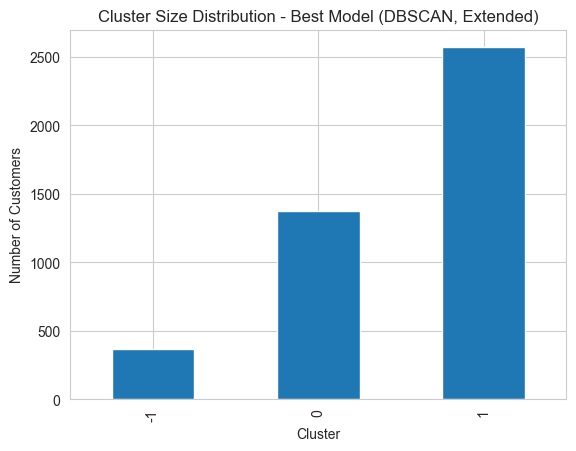

In [ ]:
best_feature_data["Cluster"].value_counts().sort_index().plot(kind="bar")
plt.title(f"Cluster Size Distribution - Best Model ({best_method}, {best_featureset})")
plt.xlabel("Cluster")
plt.ylabel("Number of Customers")
plt.show()


## 25. Cluster Profile Summary


In [ ]:
cluster_profile = best_feature_data.groupby("Cluster").mean(numeric_only=True)
cluster_profile


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseSpan,PurchaseRate,ActivityScore
Cluster,,,,,,,,,
-1,15573.175824,96.832418,4.255495,2392.485442,5.525083,33.417582,90.486264,0.714187,939.329891
0,15353.764877,153.566763,1.000000,312.360670,5.462184,21.542816,1.000000,1.000000,94.630915
1,15315.181323,56.914786,6.336965,2930.235630,5.748893,90.502724,212.056031,0.035960,1163.246081


## 26. Heatmap of Cluster Profiles


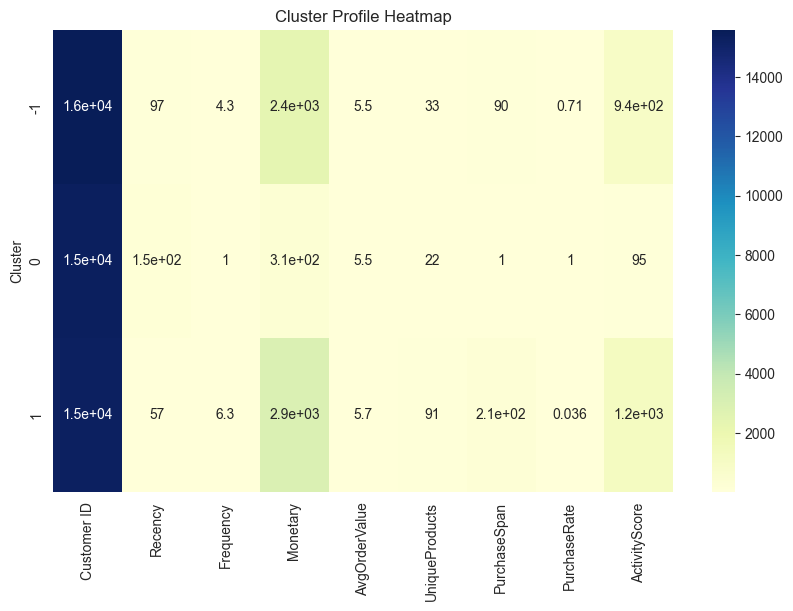

In [ ]:
plt.figure(figsize=(10, 6))
sns.heatmap(cluster_profile, annot=True, cmap="YlGnBu")
plt.title("Cluster Profile Heatmap")
plt.show()


## 27. Normalized Cluster Comparison


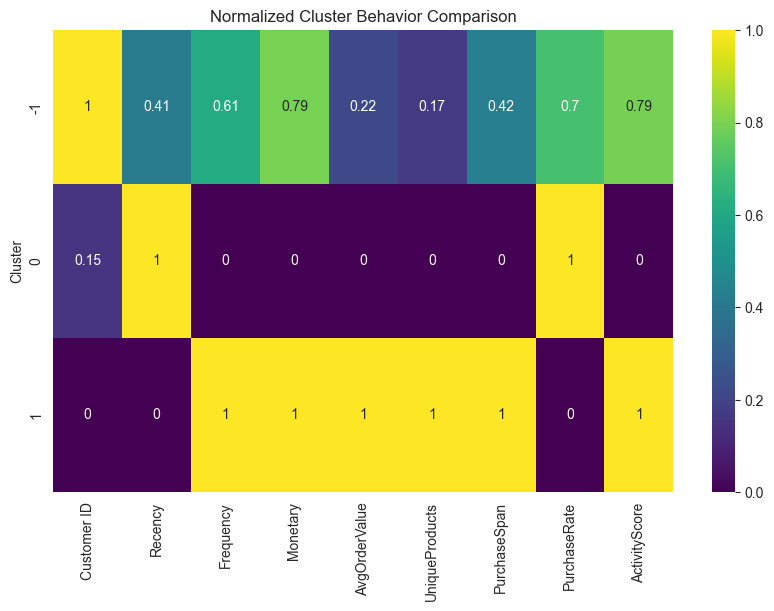

In [ ]:
normalized_profile = (cluster_profile - cluster_profile.min()) / (cluster_profile.max() - cluster_profile.min())

plt.figure(figsize=(10, 6))
sns.heatmap(normalized_profile, annot=True, cmap="viridis")
plt.title("Normalized Cluster Behavior Comparison")
plt.show()


## 28. Final PCA Plot for Best Model


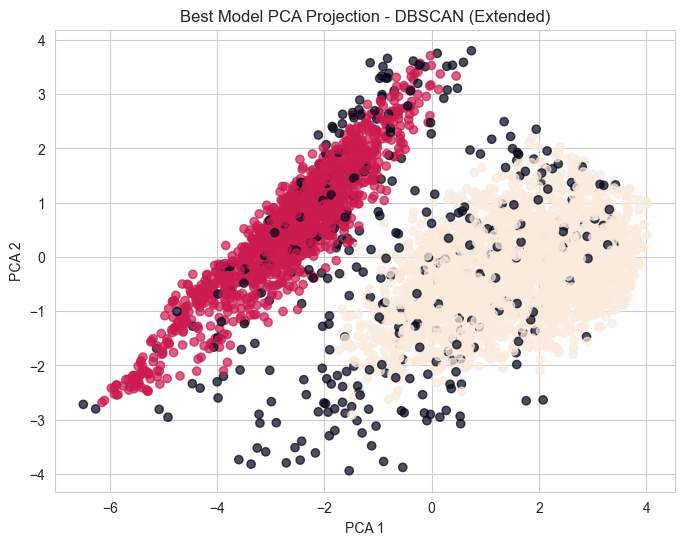

In [ ]:
plot_pca_clusters(best_scaled, best_labels, f"Best Model PCA Projection - {best_method} ({best_featureset})")


## 29. Preliminary Cluster Naming Helper

The table below shows the average feature values for each cluster produced by the selected model.

Cluster labels should be assigned based on the actual behavioral characteristics of each cluster, not from a fixed list.

For this run:
- **Champions**: lower Recency, higher Frequency, and higher Monetary value
- **At Risk**: high Recency with low Frequency and low Monetary value
- **Outliers**: DBSCAN noise points labeled as -1, representing unusual customer behavior patterns

This step converts technical clustering results into business-interpretable customer segments.

In [ ]:
print("Cluster Profile (Use this to assign labels):")
display(cluster_profile)

print("\nInterpretation Rules:")
print("- Low Recency = more recent customers (good)")
print("- High Recency = inactive customers (at risk)")
print("- High Frequency = loyal customers")
print("- High Monetary = high-value customers")
print("- Cluster -1 (if present) = Outliers (DBSCAN noise)")

Cluster Profile (Use this to assign labels):


,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseSpan,PurchaseRate,ActivityScore
Cluster,,,,,,,,,
-1,15573.175824,96.832418,4.255495,2392.485442,5.525083,33.417582,90.486264,0.714187,939.329891
0,15353.764877,153.566763,1.000000,312.360670,5.462184,21.542816,1.000000,1.000000,94.630915
1,15315.181323,56.914786,6.336965,2930.235630,5.748893,90.502724,212.056031,0.035960,1163.246081



Interpretation Rules:
- Low Recency = more recent customers (good)
- High Recency = inactive customers (at risk)
- High Frequency = loyal customers
- High Monetary = high-value customers
- Cluster -1 (if present) = Outliers (DBSCAN noise)


## 30. Cluster Naming Based on Actual Output

In [ ]:
profile = cluster_profile.copy()
profile.index = profile["Cluster"].astype(int) if "Cluster" in profile.columns else profile.index.astype(int)

# If Cluster is also a column, drop it from feature columns
if "Cluster" in profile.columns:
    profile = profile.drop(columns=["Cluster"])

cluster_names = {}

# DBSCAN noise
if -1 in profile.index:
    cluster_names[-1] = "Outliers"

real_profile = profile.drop(index=-1, errors="ignore")

# Assign labels only to clusters that actually exist
if set(real_profile.index) == {0, 1}:
    # Higher-recency cluster -> At Risk
    at_risk_idx = real_profile["Recency"].idxmax()
    cluster_names[int(at_risk_idx)] = "At Risk"

    # Remaining real cluster -> Champions
    remaining = [idx for idx in real_profile.index if idx != at_risk_idx]
    if remaining:
        cluster_names[int(remaining[0])] = "Champions"
else:
    # Generic fallback if the clustering output changes
    for idx, row in real_profile.iterrows():
        recency = row["Recency"]
        frequency = row["Frequency"]
        monetary = row["Monetary"]

        if recency > real_profile["Recency"].median() and frequency <= real_profile["Frequency"].median():
            cluster_names[int(idx)] = "At Risk"
        elif monetary > real_profile["Monetary"].median() and frequency > real_profile["Frequency"].median():
            cluster_names[int(idx)] = "Champions"
        else:
            cluster_names[int(idx)] = "Potential Loyalists"

print("Final cluster names:")
print(cluster_names)

best_feature_data["ClusterName"] = best_feature_data["Cluster"].astype(int).map(cluster_names)

best_feature_data[["Cluster", "ClusterName"]].head()

Final cluster names:
{-1: 'Outliers', 0: 'At Risk', 1: 'Champions'}


,Cluster,ClusterName
0,-1,Outliers
1,-1,Outliers
2,0,At Risk
3,1,Champions
4,0,At Risk


In [ ]:
best_feature_data["ClusterName"] = best_feature_data["Cluster"].map(cluster_names)

best_feature_data[["Cluster", "ClusterName"]].head()

,Cluster,ClusterName
0,-1,Outliers
1,-1,Outliers
2,0,At Risk
3,1,Champions
4,0,At Risk


In [ ]:
cluster_profile

,Customer ID,Recency,Frequency,Monetary,AvgOrderValue,UniqueProducts,PurchaseSpan,PurchaseRate,ActivityScore
Cluster,,,,,,,,,
-1,15573.175824,96.832418,4.255495,2392.485442,5.525083,33.417582,90.486264,0.714187,939.329891
0,15353.764877,153.566763,1.000000,312.360670,5.462184,21.542816,1.000000,1.000000,94.630915
1,15315.181323,56.914786,6.336965,2930.235630,5.748893,90.502724,212.056031,0.035960,1163.246081


## 31. Named Cluster Distribution


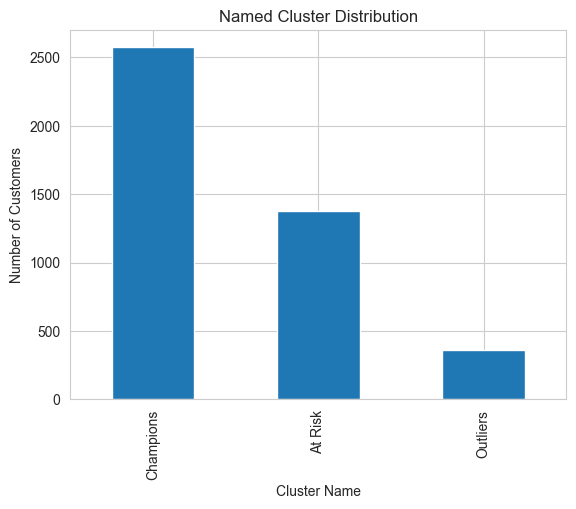

In [ ]:
best_feature_data["ClusterName"].value_counts().plot(kind="bar")
plt.title("Named Cluster Distribution")
plt.xlabel("Cluster Name")
plt.ylabel("Number of Customers")
plt.show()


## 32. Final Summary for Presentation


In [ ]:
print("Best Model:", best_method)
print("Best Feature Set:", best_featureset)
print("\nEvaluation Metrics:")
print(best_row)

print("\nCluster Names:")
print(cluster_names)

print("\nCluster Profile:")
print(cluster_profile)


Best Model: DBSCAN
Best Feature Set: Extended

Evaluation Metrics:
Method                   DBSCAN
FeatureSet             Extended
ClustersFound                 2
NoisePoints                 364
Silhouette             0.475855
DaviesBouldin           0.83735
CalinskiHarabasz    4318.948416
Name: 3, dtype: object

Cluster Names:
{-1: 'Outliers', 0: 'At Risk', 1: 'Champions'}

Cluster Profile:
          Customer ID     Recency  Frequency     Monetary  AvgOrderValue  \
Cluster                                                                    
-1       15573.175824   96.832418   4.255495  2392.485442       5.525083   
 0       15353.764877  153.566763   1.000000   312.360670       5.462184   
 1       15315.181323   56.914786   6.336965  2930.235630       5.748893   

         UniqueProducts  PurchaseSpan  PurchaseRate  ActivityScore  
Cluster                                                             
-1            33.417582     90.486264      0.714187     939.329891  
 0            21.

## 33. Save Outputs


In [ ]:
from pathlib import Path

project_root = Path.cwd()
if project_root.name == "notebooks":
    project_root = project_root.parent

output_dir = project_root / "outputs"
output_dir.mkdir(exist_ok=True)

model_comparison_path = output_dir / "final_model_comparison.csv"
cluster_profile_path = output_dir / "final_cluster_profile.csv"
best_model_customers_path = output_dir / "final_best_model_customers.csv"

results.to_csv(model_comparison_path, index=False)
cluster_profile.to_csv(cluster_profile_path)
best_feature_data.to_csv(best_model_customers_path, index=False)


## 34. Conclusion

In this project, we developed an improved customer segmentation framework by extending the baseline RFM-based pipeline with additional behavioral features.

We evaluated multiple clustering approaches, including K-Means, Hierarchical Clustering, and DBSCAN, using several evaluation metrics such as Silhouette Score, Davies-Bouldin Index, and Calinski-Harabasz Score.

The experimental results show that DBSCAN achieved the best cluster separation, while K-Means demonstrated stronger cluster compactness. This highlights an important trade-off between cluster separation and compactness across different clustering methods.

The final segmentation identified three meaningful customer groups: Champions, At-Risk customers, and Outliers. These segments provide actionable insights for targeted marketing strategies, customer retention, and business decision-making.

Overall, this work demonstrates that combining feature engineering with multiple clustering techniques significantly improves customer segmentation quality and provides a more realistic representation of customer behavior.